**1. Introdução**

Nesta fase do CardioIA, implementamos um Assistente Cardiológico Virtual
baseado em Visão Computacional para auxiliar a interpretação de imagens de ECG.

**2. Importação das bibliotecas**

In [6]:
import tensorflow as tf

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

from tensorflow.keras.layers import Rescaling

**3. Carregamento do dataset**

In [12]:
DATASET_PATH = "/content/drive/MyDrive/CardioIA_Fase4/dataset"

In [13]:
import os

print(os.listdir(DATASET_PATH))

['Normal', 'Myocardial_Infarction', 'Previous_MI', 'Abnormal_Heartbeat']


**4. Pré-processamento**

*   4.1 Redimensionamento



In [17]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

4.2 Verificação do dataset



In [15]:
import os

for pasta in os.listdir(DATASET_PATH):

    caminho = os.path.join(DATASET_PATH, pasta)

    if os.path.isdir(caminho):

        print(
            pasta,
            ":",
            len(os.listdir(caminho)),
            "imagens"
        )

Normal : 241 imagens
Myocardial_Infarction : 239 imagens
Previous_MI : 172 imagens
Abnormal_Heartbeat : 233 imagens


4.3 Explicação

As imagens foram organizadas em quatro classes, redimensionadas para 224x224 pixels e preparadas para o treinamento dos modelos de Visão Computacional. Esse tamanho foi escolhido por ser compatível com arquiteturas pré-treinadas utilizadas posteriormente no Transfer Learning.

**5. Separação treino/validação/teste**

In [18]:
import pathlib

DATASET_PATH = pathlib.Path(DATASET_PATH)

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Número de classes:", num_classes)

Found 885 files belonging to 4 classes.
Using 620 files for training.
Found 885 files belonging to 4 classes.
Using 265 files for validation.
Classes: ['Abnormal_Heartbeat', 'Myocardial_Infarction', 'Normal', 'Previous_MI']
Número de classes: 4


In [19]:
val_batches = tf.data.experimental.cardinality(temp_ds)

test_ds = temp_ds.take(val_batches // 2)

val_ds = temp_ds.skip(val_batches // 2)

print("Batches de treino:", tf.data.experimental.cardinality(train_ds).numpy())
print("Batches de validação:", tf.data.experimental.cardinality(val_ds).numpy())
print("Batches de teste:", tf.data.experimental.cardinality(test_ds).numpy())

Batches de treino: 20
Batches de validação: 5
Batches de teste: 4


**Separação dos dados**

O dataset foi dividido em três conjuntos: treino, validação e teste. O conjunto de treino foi utilizado para ensinar o modelo a identificar padrões presentes nas imagens de ECG. O conjunto de validação foi utilizado para acompanhar o desempenho durante o desenvolvimento e ajustar a solução, enquanto o conjunto de teste foi reservado para a avaliação final do modelo em dados não utilizados no treinamento.

Foi adotada uma divisão aproximada de 70% para treino, 15% para validação e 15% para teste, garantindo uma avaliação mais confiável da capacidade de generalização do modelo.

In [22]:
total_imagens = 885

treino = int(total_imagens * 0.70)

restante = total_imagens - treino

teste = restante // 2

validacao = restante - teste

print(f"Total: {total_imagens} imagens")
print(f"Treino: {treino} imagens")
print(f"Validação: {validacao} imagens")
print(f"Teste: {teste} imagens")

Total: 885 imagens
Treino: 619 imagens
Validação: 133 imagens
Teste: 133 imagens


**6. CNN treinada do zero**

**6.1 Explicação**

A primeira abordagem utiliza uma Rede Neural Convolucional (CNN) desenvolvida do zero. O modelo possui camadas convolucionais para extração de características das imagens de ECG, camadas de pooling para redução dimensional e camadas densas para realizar a classificação das quatro categorias do dataset.

**6.2 Construção do modelo**

In [23]:
model_cnn = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**6.3 Treinamento do modelo**

In [24]:
EPOCHS = 10

history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 145s 7s/step - accuracy: 0.2468 - loss: 2.0086 - val_accuracy: 0.2190 - val_loss: 1.3786
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.3032 - loss: 1.3537 - val_accuracy: 0.4015 - val_loss: 1.3613
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.4452 - loss: 1.2092 - val_accuracy: 0.3358 - val_loss: 1.3891
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.6016 - loss: 0.9741 - val_accuracy: 0.6861 - val_loss: 0.8068
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.7161 - loss: 0.7101 - val_accuracy: 0.7518 - val_loss: 0.7328
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.8468 - loss: 0.4602 - val_accuracy: 0.8467 - val_loss: 0.4720
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 154s 5s/step - accuracy: 0.8774 - loss: 0.3482 - val_accuracy: 0.8613 - val_loss: 0.4367
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 132s 4s/step - accuracy: 0.9484 - loss: 0.1869 - val_accuracy: 0.8978 - val_lo

**6.4 Visualização dos resultados**

Foram gerados gráficos de acurácia e perda (loss) para acompanhar o desempenho da CNN durante o treinamento. A comparação entre os conjuntos de treino e validação permite identificar a capacidade de generalização do modelo e possíveis sinais de overfitting.

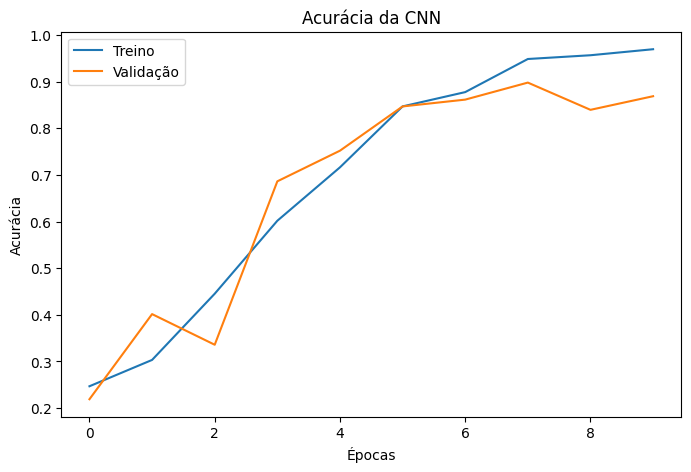

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'])

plt.plot(history_cnn.history['val_accuracy'])

plt.title('Acurácia da CNN')

plt.xlabel('Épocas')

plt.ylabel('Acurácia')

plt.legend(['Treino', 'Validação'])

plt.show()

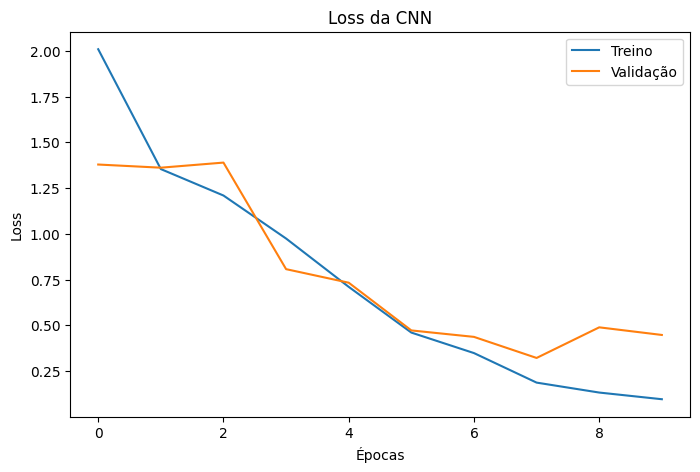

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'])

plt.plot(history_cnn.history['val_loss'])

plt.title('Loss da CNN')

plt.xlabel('Épocas')

plt.ylabel('Loss')

plt.legend(['Treino', 'Validação'])

plt.show()

Observou-se um leve overfitting nas últimas épocas, pois a acurácia do conjunto de treino continuou aumentando enquanto a acurácia de validação apresentou uma pequena queda. Apesar disso, o modelo demonstrou boa capacidade de generalização para um dataset relativamente pequeno.

**7. Transfer Learning com ResNet50 ou VGG16**

Nesta etapa, foi utilizada a técnica de Transfer Learning com a arquitetura ResNet50 pré-treinada na base ImageNet. Essa abordagem permite reutilizar conhecimentos previamente aprendidos em grandes volumes de imagens, reduzindo o tempo de treinamento e melhorando a capacidade de generalização dos modelos. Neste projeto, a base convolucional foi mantida congelada e apenas as camadas finais foram treinadas para a classificação das imagens de ECG.

**7.2 Construção do modelo**

A arquitetura ResNet50 foi utilizada como extratora de características. Após a etapa de extração, foram adicionadas camadas densas responsáveis pela classificação das quatro categorias presentes no dataset.

**7.3 Treinamento do modelo**

O treinamento foi realizado utilizando o conjunto de treino e acompanhado pelo conjunto de validação ao longo de 10 épocas. O objetivo foi observar a evolução da acurácia e da função de perda durante o processo de aprendizagem.

In [27]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_resnet = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_resnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
EPOCHS = 10

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 158s 7s/step - accuracy: 0.2968 - loss: 1.4625 - val_accuracy: 0.2409 - val_loss: 1.3562
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 140s 7s/step - accuracy: 0.3048 - loss: 1.3816 - val_accuracy: 0.3796 - val_loss: 1.3767
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 145s 7s/step - accuracy: 0.3355 - loss: 1.3669 - val_accuracy: 0.3869 - val_loss: 1.3587
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 141s 7s/step - accuracy: 0.3097 - loss: 1.3738 - val_accuracy: 0.4161 - val_loss: 1.3162
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 144s 7s/step - accuracy: 0.3742 - loss: 1.3523 - val_accuracy: 0.2628 - val_loss: 1.3528
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 215s 8s/step - accuracy: 0.3694 - loss: 1.3375 - val_accuracy: 0.3504 - val_loss: 1.3392
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 147s 7s/step - accuracy: 0.3887 - loss: 1.3244 - val_accuracy: 0.3431 - val_loss: 1.3315
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 195s 7s/step - accuracy: 0.3500 - loss: 1.3267 - val_accuracy: 0.3577 - v

**7.4 Visualização dos resultados**

Foram gerados gráficos de acurácia e perda (loss) para analisar o comportamento da ResNet50 durante o treinamento. A comparação entre treino e validação permite verificar a capacidade de generalização do modelo e identificar possíveis dificuldades de adaptação ao dataset utilizado.

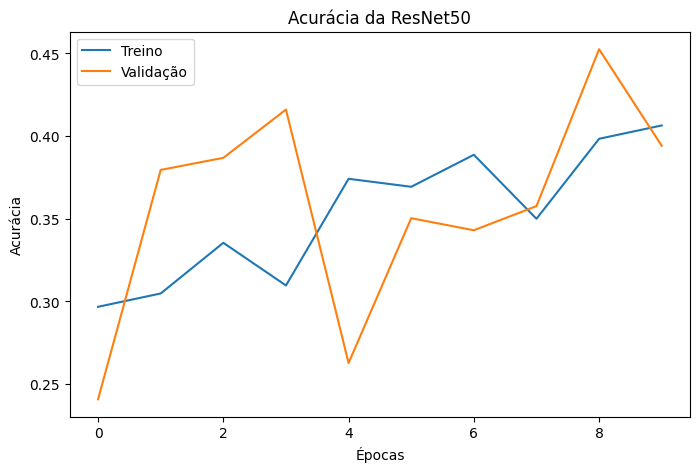

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history['accuracy'])

plt.plot(history_resnet.history['val_accuracy'])

plt.title('Acurácia da ResNet50')

plt.xlabel('Épocas')

plt.ylabel('Acurácia')

plt.legend(['Treino', 'Validação'])

plt.show()

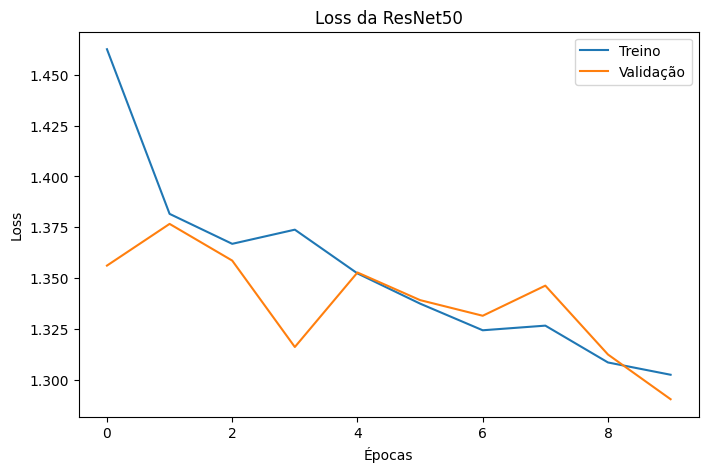

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history['loss'])

plt.plot(history_resnet.history['val_loss'])

plt.title('Loss da ResNet50')

plt.xlabel('Épocas')

plt.ylabel('Loss')

plt.legend(['Treino', 'Validação'])

plt.show()

Diferentemente da CNN treinada do zero, a ResNet50 apresentou um desempenho inferior. Isso pode ter ocorrido devido ao tamanho reduzido do dataset e ao fato de a base convolucional permanecer congelada. Como a ResNet50 foi originalmente treinada em imagens genéricas, a adaptação para imagens de ECG pode exigir mais dados ou um ajuste fino (fine-tuning) adicional.

**8. Avaliação dos modelos**

Nesta etapa, os modelos CNN e ResNet50 foram avaliados utilizando o conjunto de teste. Foram utilizadas as métricas de acurácia, precisão (precision), revocação (recall) e F1-score para comparar o desempenho das duas abordagens.

In [31]:
y_true_cnn = []
y_pred_cnn = []

for imagens, labels in test_ds:

    predictions = model_cnn.predict(imagens)

    y_true_cnn.extend(labels.numpy())

    y_pred_cnn.extend(
        np.argmax(predictions, axis=1)
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step


In [32]:
print(
    classification_report(
        y_true_cnn,
        y_pred_cnn,
        target_names=class_names
    )
)

                       precision    recall  f1-score   support

   Abnormal_Heartbeat       0.85      0.81      0.83        36
Myocardial_Infarction       1.00      1.00      1.00        37
               Normal       0.81      0.83      0.82        30
          Previous_MI       0.65      0.68      0.67        25

             accuracy                           0.84       128
            macro avg       0.83      0.83      0.83       128
         weighted avg       0.85      0.84      0.84       128



In [33]:
y_true_resnet = []
y_pred_resnet = []

for imagens, labels in test_ds:

    predictions = model_resnet.predict(imagens)

    y_true_resnet.extend(labels.numpy())

    y_pred_resnet.extend(
        np.argmax(predictions, axis=1)
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [35]:
print(
    classification_report(
        y_true_resnet,
        y_pred_resnet,
        target_names=class_names,
        zero_division=0
    )
)

                       precision    recall  f1-score   support

   Abnormal_Heartbeat       0.32      0.93      0.47        28
Myocardial_Infarction       0.62      0.45      0.53        33
               Normal       0.41      0.26      0.32        34
          Previous_MI       0.00      0.00      0.00        33

             accuracy                           0.39       128
            macro avg       0.34      0.41      0.33       128
         weighted avg       0.34      0.39      0.32       128



CNN treinada do zero apresentou desempenho significativamente superior ao modelo ResNet50. Enquanto a CNN atingiu aproximadamente 84% de acurácia, a ResNet50 obteve aproximadamente 39%.

O resultado demonstra que modelos pré-treinados nem sempre apresentam melhor desempenho em datasets pequenos e especializados. Como a ResNet50 foi originalmente treinada na base ImageNet, composta por imagens genéricas, sua adaptação para imagens de ECG pode exigir um volume maior de dados ou técnicas adicionais de fine-tuning.

A CNN desenvolvida especificamente para este projeto conseguiu aprender melhor os padrões presentes nas imagens do dataset.

| Métrica         | CNN | ResNet50 |
| --------------- | --- | -------- |
| Accuracy        | 84% | 39%      |
| Macro Precision | 83% | 34%      |
| Macro Recall    | 83% | 41%      |
| Macro F1-score  | 83% | 33%      |


**9. Matrizes de confusão**

A matriz de confusão permite visualizar a quantidade de classificações corretas e incorretas realizadas pelos modelos. As linhas representam as classes reais e as colunas representam as classes previstas pelo modelo. Quanto maiores os valores na diagonal principal, melhor o desempenho do modelo.

**9.1 Matriz da CNN**

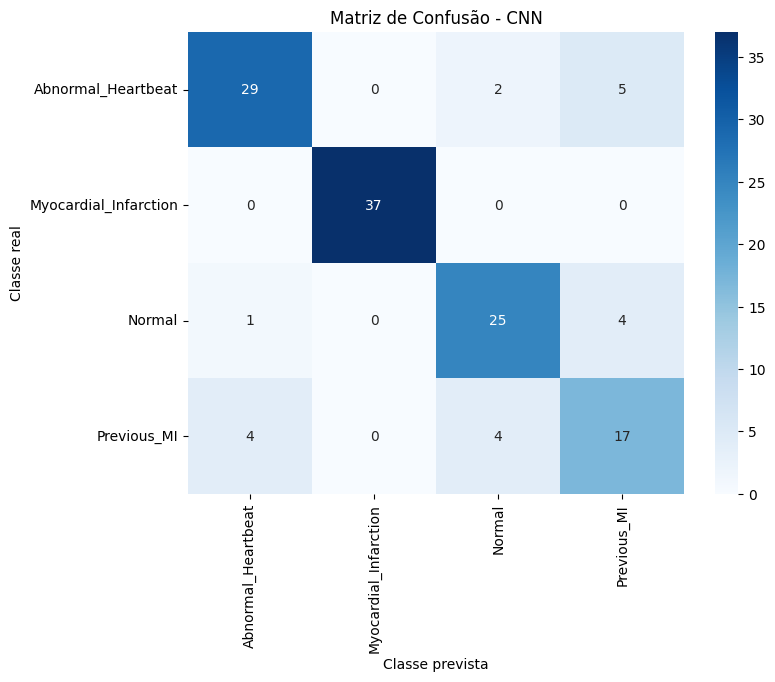

In [36]:
cm_cnn = confusion_matrix(
    y_true_cnn,
    y_pred_cnn
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Matriz de Confusão - CNN')

plt.xlabel('Classe prevista')

plt.ylabel('Classe real')

plt.show()

**9.2 Matriz da ResNet50**

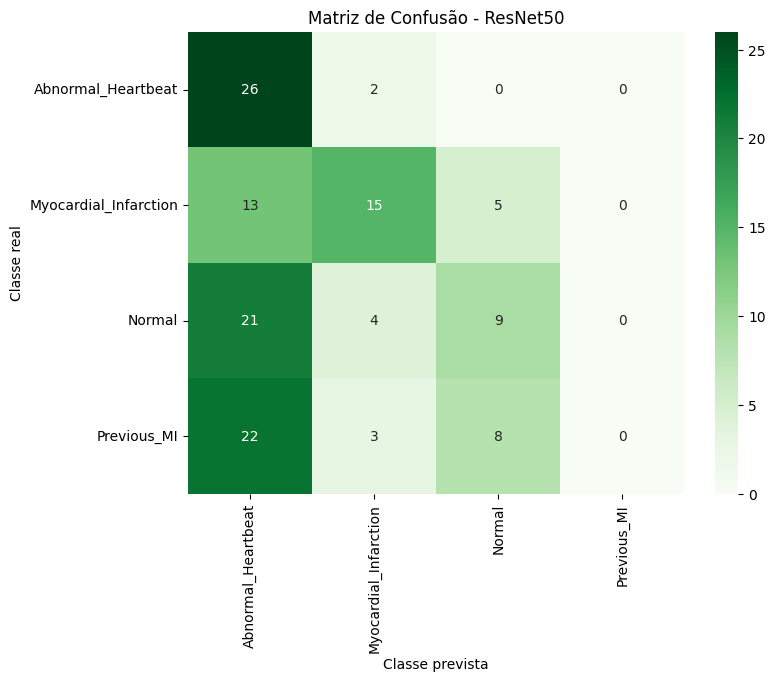

In [37]:
cm_resnet = confusion_matrix(
    y_true_resnet,
    y_pred_resnet
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Matriz de Confusão - ResNet50')

plt.xlabel('Classe prevista')

plt.ylabel('Classe real')

plt.show()

As matrizes de confusão demonstram diferenças significativas entre os dois modelos implementados. A CNN treinada do zero apresentou maior concentração de acertos na diagonal principal, indicando uma boa capacidade de generalização.

O destaque ficou para a classe Myocardial_Infarction, que obteve 100% de acerto na CNN. As maiores dificuldades ocorreram na classe Previous_MI, que apresentou algumas confusões com as classes Abnormal_Heartbeat e Normal.

A ResNet50 apresentou um desempenho inferior, concentrando diversas previsões na classe Abnormal_Heartbeat e falhando completamente na identificação da classe Previous_MI. Esse comportamento evidencia a limitação da aplicação direta de modelos pré-treinados em datasets pequenos e altamente especializados.

**10. Protótipo de upload e classificação**

Foi desenvolvido um protótipo simples utilizando o próprio Google Colab. O usuário pode realizar o upload de uma imagem de ECG e receber a classificação prevista pelo modelo, juntamente com a confiança da predição. Para o protótipo final, foi utilizado o modelo CNN, pois apresentou desempenho superior ao Transfer Learning com ResNet50.

**10.1 Interface de upload**

In [39]:
from google.colab import files

uploaded = files.upload()

Saving Normal(1).jpg to Normal(1).jpg


**10.2 Classificação da imagem**

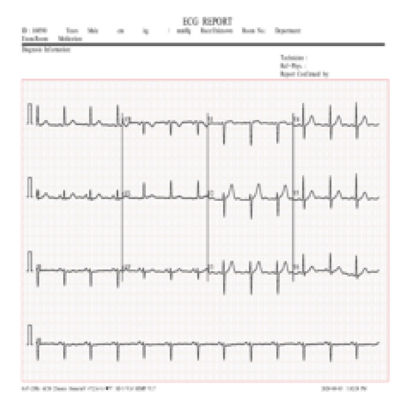

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Classe prevista: Normal
Confiança: 78.92%


In [40]:
from PIL import Image

for filename in uploaded.keys():

    img = Image.open(filename).convert("RGB")

    img = img.resize((224,224))

    plt.figure(figsize=(5,5))

    plt.imshow(img)

    plt.axis('off')

    plt.show()

    img_array = np.array(img)

    img_array = np.expand_dims(img_array, axis=0)

    prediction = model_cnn.predict(img_array)

    classe = class_names[np.argmax(prediction)]

    confianca = np.max(prediction) * 100

    print(f"Classe prevista: {classe}")

    print(f"Confiança: {confianca:.2f}%")

No teste realizado com uma imagem da classe Normal, o protótipo classificou corretamente a imagem como Normal, com confiança de 78,92%. Esse resultado demonstra o funcionamento da interface interativa no Google Colab e a capacidade do modelo CNN em realizar classificações simuladas a partir de novas imagens de ECG.

**10.3 Aviso ético**

Aviso: Este protótipo possui finalidade exclusivamente educacional e experimental. Os resultados apresentados não substituem a avaliação de profissionais da saúde e não devem ser utilizados para fins diagnósticos.

**11. Conclusão**

Neste projeto, foi desenvolvido um protótipo de Assistente Cardiológico Virtual com Visão Computacional para classificação de imagens de ECG. Foram aplicadas etapas de pré-processamento, separação dos dados em treino, validação e teste, treinamento de uma CNN do zero e implementação de Transfer Learning com ResNet50.

A CNN apresentou melhor desempenho, atingindo aproximadamente 84% de acurácia no conjunto de teste, enquanto a ResNet50 obteve desempenho inferior. Esse resultado indica que, para o dataset utilizado, uma arquitetura mais simples e treinada especificamente para as imagens de ECG foi mais eficiente do que o uso direto de um modelo pré-treinado em imagens genéricas.

O protótipo final, implementado no Google Colab, permitiu realizar o upload de uma imagem de ECG e obter uma classificação simulada com percentual de confiança. Em um teste com uma imagem da classe Normal, o modelo classificou corretamente a imagem com 78,92% de confiança.

Apesar dos resultados positivos, a solução possui finalidade exclusivamente educacional e experimental. Para aplicação real em saúde, seria necessário utilizar bases maiores, realizar validação clínica com especialistas, tratar possíveis vieses nos dados e garantir conformidade com normas de privacidade e segurança.